In [28]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

DATA UNDERSTANDING

In [29]:
df = pd.DataFrame(pd.read_csv("Combined Data.csv"))
print("--- Initial Data Head (50 Rows) ---")
print(df.head(50))
print("\nJumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Column 'Unnamed: 0' dropped.")

--- Initial Data Head (50 Rows) ---
    Unnamed: 0                                          statement   status
0            0                                         oh my gosh  Anxiety
1            1  trouble sleeping, confused mind, restless hear...  Anxiety
2            2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3            3  I've shifted my focus to something else but I'...  Anxiety
4            4  I'm restless and restless, it's been a month n...  Anxiety
5            5  every break, you must be nervous, like somethi...  Anxiety
6            6  I feel scared, anxious, what can I do? And may...  Anxiety
7            7    Have you ever felt nervous but didn't know why?  Anxiety
8            8  I haven't slept well for 2 days, it's like I'm...  Anxiety
9            9                 I'm really worried, I want to cry.  Anxiety
10          10  always restless every night, even though I don...  Anxiety
11          11  I'm confused, I'm not feeling good lately. Eve..

In [30]:
df["length"] = df["statement"].astype(str).apply(lambda x: len(x.split()))
print("\nPanjang rata-rata setiap baris:", df["length"].mean())


Panjang rata-rata setiap baris: 112.39328469355051


In [31]:
# print("Jumlah duplikasi:", df.duplicated().sum())

In [32]:
print("\nMissing values before filtering:")
print(df.isnull().sum())


Missing values before filtering:
statement    362
status         0
length         0
dtype: int64


In [33]:
print("\nStatus value counts after filtering:")
print(df['status'].value_counts())


Status value counts after filtering:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [34]:
labels_to_keep = ['Depression', 'Normal', 'Suicidal']
df = df[df['status'].isin(labels_to_keep)].reset_index(drop=True)

In [35]:
print("\nMissing values after filtering:")
print(df.isnull().sum())


Missing values after filtering:
statement    9
status       0
length       0
dtype: int64


In [36]:
df['statement'] = df['statement'].fillna('')

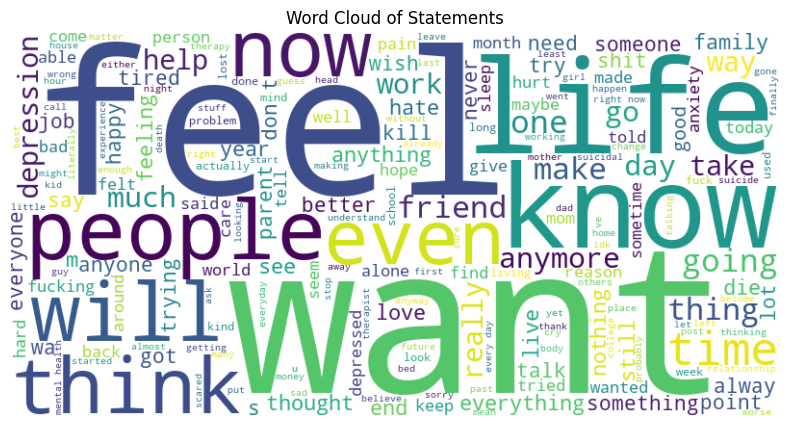

In [37]:
all_text = " ".join(df["statement"].astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Statements")
plt.show()

TEXT PREPROCESSING

In [38]:
def preprocess_text(text):
    text = text.lower()
    
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
  
    text = re.sub(r"[^\w\s\.,!?']", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_statement"] = df["statement"].astype(str).apply(preprocess_text)

print("\n--- Cleaned Statement Head ---")
print(df[["statement", "cleaned_statement"]].head())


--- Cleaned Statement Head ---
                                           statement  \
0      Gr gr dreaming of ex crush to be my game, God   
1                                 wkwkwk what a joke   
2  Leaves are also standby in front of the PC ......   
3     Thank God even though it's just a ride through   
4  wedding teaser concept using the song day6 - o...   

                                   cleaned_statement  
0      gr gr dreaming of ex crush to be my game, god  
1                                 wkwkwk what a joke  
2  leaves are also standby in front of the pc ......  
3     thank god even though it's just a ride through  
4  wedding teaser concept using the song day6 onl...  


In [39]:
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

df["tokenized_statement"] = df["cleaned_statement"].apply(word_tokenize)
df["sent_tokenized_statement"] = df["cleaned_statement"].apply(sent_tokenize)
print("\n--- Tokenized Statement Head (10 Rows) ---")
print(df[["cleaned_statement", "tokenized_statement", "sent_tokenized_statement"]].head(10))


--- Tokenized Statement Head (10 Rows) ---
                                   cleaned_statement  \
0      gr gr dreaming of ex crush to be my game, god   
1                                 wkwkwk what a joke   
2  leaves are also standby in front of the pc ......   
3     thank god even though it's just a ride through   
4  wedding teaser concept using the song day6 onl...   
5                                        no comeback   
6                            sender my sc on weirdðÿ   
7                                  1.7 fucking years   
8  bismillah for eid 2021, you get a few question...   
9          why is the call to prayer taking so long?   

                                 tokenized_statement  \
0  [gr, gr, dreaming, of, ex, crush, to, be, my, ...   
1                            [wkwkwk, what, a, joke]   
2  [leaves, are, also, standby, in, front, of, th...   
3  [thank, god, even, though, it, 's, just, a, ri...   
4  [wedding, teaser, concept, using, the, song, d...   
5  

In [40]:
vectorizer = TfidfVectorizer(max_features=3000, sublinear_tf=True, min_df=2)
X = vectorizer.fit_transform(df['cleaned_statement'])

y = df['status']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [42]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

# Menggunakan RandomOverSampler:
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("\n--- Data Split and Resampling (RandomOverSampler) ---")
print(f"Original Training shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled Training shape: {X_train_ros.shape}, {y_train_ros.shape}")
print("Y Training (Resampled) Value Counts:")
print(y_train_ros.value_counts())


--- Data Split and Resampling (RandomOverSampler) ---
Original Training shape: (33926, 3000), (33926,)
Resampled Training shape: (39243, 3000), (39243,)
Y Training (Resampled) Value Counts:
status
Depression    13081
Normal        13081
Suicidal      13081
Name: count, dtype: int64


MODELING SVM

algoritma machine learning yang digunakan untuk klasifikasi dan regresi dengan cara menemukan hyperplane (garis pemisah) terbaik yang memaksimalkan margin atau jarak antara dua atau lebih kelompok data

In [43]:
print("\n--- SVM Model Training ---")
model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train) 
    


--- SVM Model Training ---


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


EVALUATION

In [44]:
y_pred = model.predict(X_test)

CONFUSION MATRIX

In [45]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)


--- Confusion Matrix ---


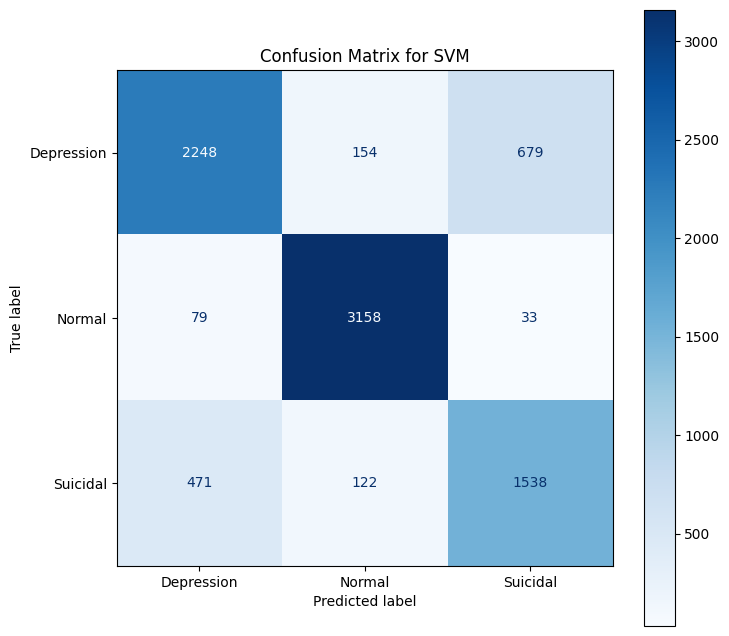

In [46]:
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for SVM")
plt.show()

In [47]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))


--- Classification Report ---
              precision    recall  f1-score   support

  Depression     0.8034    0.7296    0.7648      3081
      Normal     0.9196    0.9657    0.9421      3270
    Suicidal     0.6836    0.7217    0.7021      2131

    accuracy                         0.8187      8482
   macro avg     0.8022    0.8057    0.8030      8482
weighted avg     0.8181    0.8187    0.8174      8482



DATA PREDICTION

In [48]:
def predict_statement(statement):
    cleaned_statement = preprocess_text(statement)
    # Use the fitted vectorizer
    vectorized_statement = vectorizer.transform([cleaned_statement])
    prediction = model.predict(vectorized_statement)
    return prediction[0]

# Test cases
test_statements = [
    "I feel hopeless lately.",
    "I’ve been feeling unhappy most days.",
    "Everything seems pointless.",
    "I am planning to end my life soon.",
    "I feel normal and happy today.",
    "I have no reason to live anymore."
]

print("\n--- Test Predictions ---")
for stmt in test_statements:
    result = predict_statement(stmt)
    print(f"Statement: '{stmt}' => Predicted Status: {result}")


--- Test Predictions ---
Statement: 'I feel hopeless lately.' => Predicted Status: Suicidal
Statement: 'I’ve been feeling unhappy most days.' => Predicted Status: Normal
Statement: 'Everything seems pointless.' => Predicted Status: Normal
Statement: 'I am planning to end my life soon.' => Predicted Status: Suicidal
Statement: 'I feel normal and happy today.' => Predicted Status: Depression
Statement: 'I have no reason to live anymore.' => Predicted Status: Suicidal
